# Practical 14: Movie Recommendation System (Content-Based)

## Objective
To build a content-based movie recommender system that suggests similar movies using text vectorization and cosine similarity.

## Import Libraries

In [10]:
import numpy as np
import pandas as pd
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Load Dataset

In [11]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv', encoding='latin1')

movies = movies.merge(credits, on='title')
movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
movies.dropna(inplace=True)

movies.head()

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Data Preprocessing

In [12]:
def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [13]:
def convert_cast(text):
    L = []
    for i in ast.literal_eval(text)[:3]:
        L.append(i['name'])
    return L

movies['cast'] = movies['cast'].apply(convert_cast)

In [14]:
def fetch_director(text):
    L = []
    for i in ast.literal_eval(text):
        if i['job'] == 'Director':
            L.append(i['name'])
    return L

movies['crew'] = movies['crew'].apply(fetch_director)

## Feature Engineering

In [15]:
movies['overview'] = movies['overview'].apply(lambda x: x.split())

for col in ['genres','keywords','cast','crew']:
    movies[col] = movies[col].apply(lambda x: [i.replace(" ","") for i in x])

movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [16]:
new_df = movies[['movie_id','title','tags']]
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

/tmp/ipykernel_13953/3488699016.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))
/tmp/ipykernel_13953/3488699016.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())


## Vectorization

In [17]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

## Similarity Matrix

In [18]:
similarity = cosine_similarity(vectors)

## Recommendation Function

In [19]:
def recommend(movie):
    if movie not in new_df['title'].values:
        print("Movie not found!")
        return

    index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[index]

    movies_list = sorted(list(enumerate(distances)), key=lambda x:x[1], reverse=True)[1:6]

    print("\nRecommended Movies:\n")
    for i in movies_list:
        print(new_df.iloc[i[0]].title)

## Test Recommendation

In [20]:
recommend('Avatar')


Recommended Movies:

Titan A.E.
Small Soldiers
Independence Day
Aliens vs Predator: Requiem
Lifeforce


## Similarity Heatmap

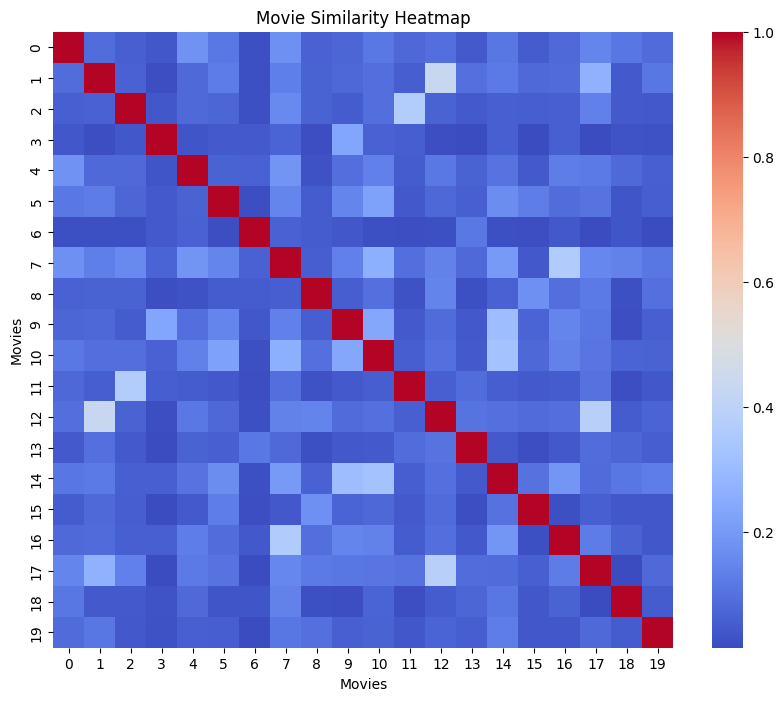

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Take small subset (otherwise 5000x5000 is too big)
subset = similarity[:20, :20]

plt.figure(figsize=(10,8))
sns.heatmap(subset, cmap='coolwarm')
plt.title("Movie Similarity Heatmap")
plt.xlabel("Movies")
plt.ylabel("Movies")
plt.show()

## Top 10 Recommended Movies Bar Chart

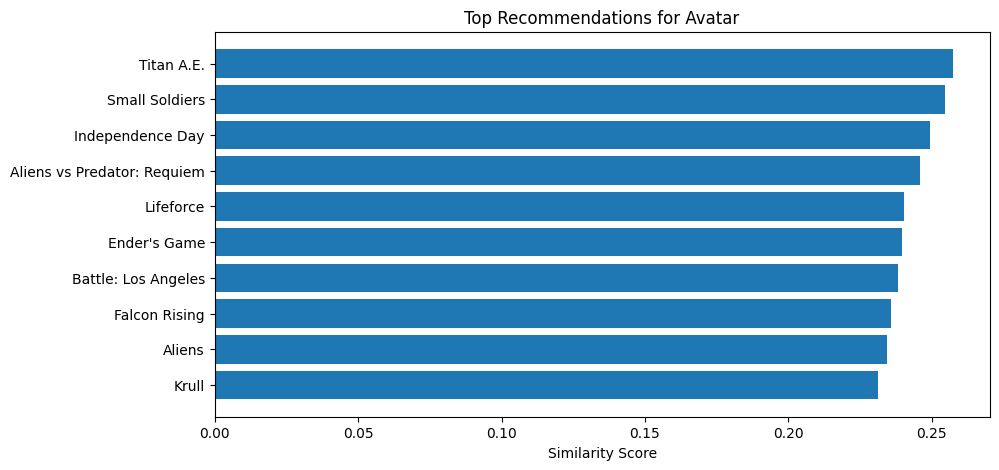

In [22]:
def visualize_recommendations(movie):
    if movie not in new_df['title'].values:
        print("Movie not found!")
        return

    index = new_df[new_df['title'] == movie].index[0]
    distances = list(enumerate(similarity[index]))
    movies_list = sorted(distances, reverse=True, key=lambda x: x[1])[1:11]

    names = []
    scores = []

    for i in movies_list:
        names.append(new_df.iloc[i[0]].title)
        scores.append(i[1])

    plt.figure(figsize=(10,5))
    plt.barh(names[::-1], scores[::-1])
    plt.xlabel("Similarity Score")
    plt.title(f"Top Recommendations for {movie}")
    plt.show()

# Example
visualize_recommendations('Avatar')

## Word Frequency

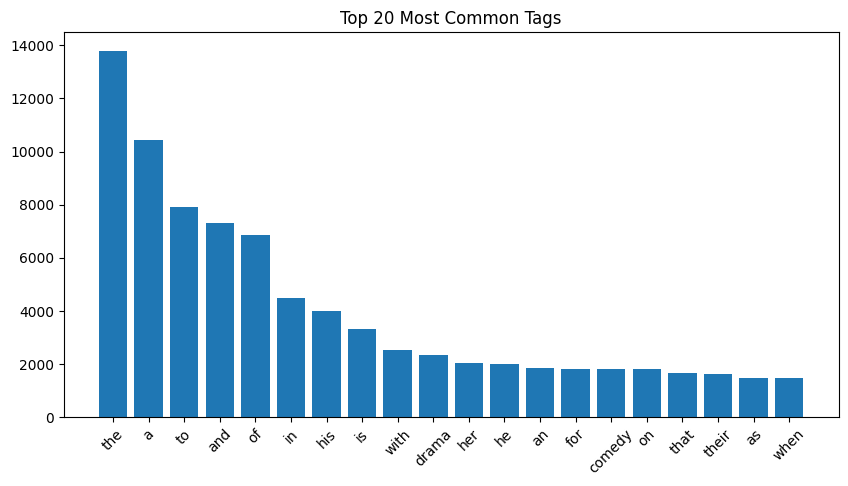

In [23]:
from collections import Counter

all_words = " ".join(new_df['tags']).split()
common_words = Counter(all_words).most_common(20)

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Tags")
plt.show()

## WordCloud

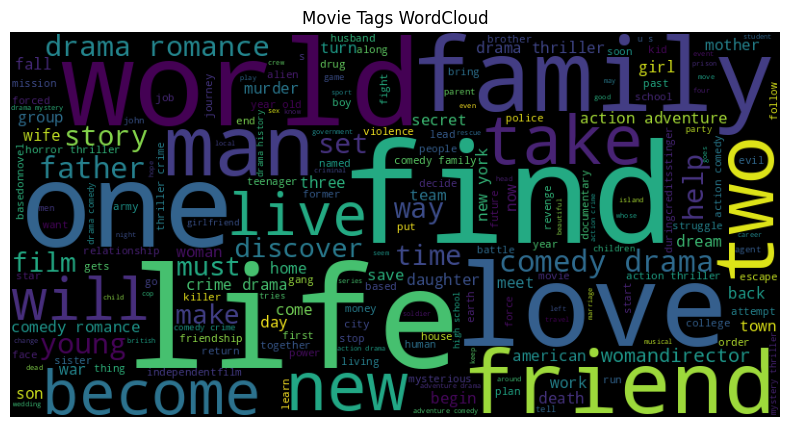

In [24]:
from wordcloud import WordCloud

text = " ".join(new_df['tags'])

wc = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title("Movie Tags WordCloud")
plt.show()

## Distribution of Similarity Scores

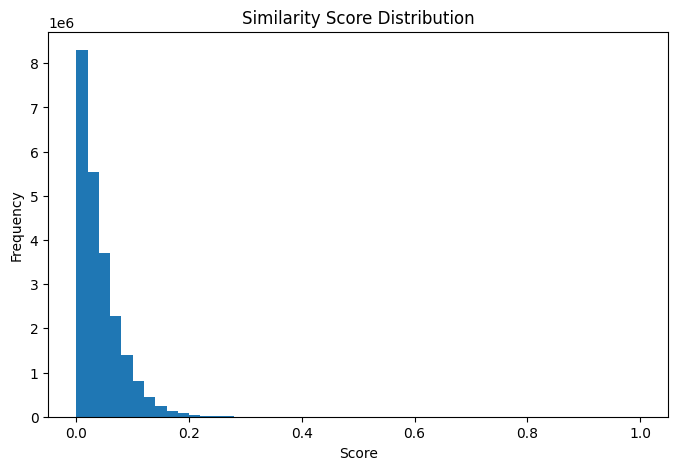

In [25]:
import numpy as np

plt.figure(figsize=(8,5))
plt.hist(similarity.flatten(), bins=50)
plt.title("Similarity Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

## Conclusion

The content-based recommender system successfully suggests similar movies using text features and cosine similarity.